<a href="https://colab.research.google.com/github/nauerromero/Ciencia_de_Datos_II/blob/main/ArchivosCasoPractico2/CasoPractico2_Colaborativo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Cloning into 'Ciencia_de_Datos_II'...
remote: Enumerating objects: 684, done.
remote: Counting objects: 100% (1/1), done.
remote: Total 684 (delta 0), reused 0 (delta 0), pack-reused 683 (from 2)
Receiving objects: 100% (684/684), 192.42 MiB | 22.81 MiB/s, done.
Resolving deltas: 100% (33/33), done.
Updating files: 100% (610/610), done.
/content/Ciencia_de_Datos_II/ArchivosCasoPractico2/dataset_sample/train
Found 480 images belonging to 2 classes.
Found 120 images belonging to 2 classes.

Entrenando Model_1...
Epoch 1/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 15s 919ms/step - accuracy: 0.5302 - loss: 2.6280 - val_accuracy: 0.7083 - val_loss: 0.5419
Epoch 2/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 13s 880ms/step - accuracy: 0.8041 - loss: 0.4705 - val_accuracy: 0.8333 - val_loss: 0.4026
Epoch 3/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 13s 876ms/step - accuracy: 0.8632 - loss: 0.3520 - val_accuracy: 0.8833 - val_loss: 0.2862
Epoch 4/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 13s 871ms/step - accuracy: 0.9290 - loss: 0.2105 - val_accuracy

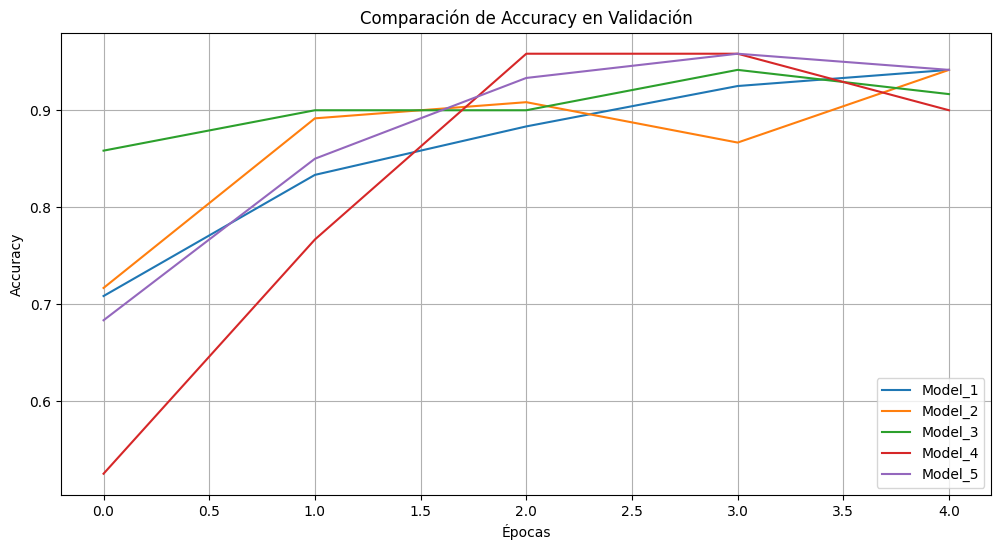

✅ Entrenamiento completado. Los modelos fueron calibrados sobre la muestra significativa.
📁 Dataset usado: 300 imágenes por clase (NORMAL vs PNEUMONIA)
📊 Visualización emocional: cada curva representa una intención distinta de lectura diagnóstica.
🧘 Ritual de cierre: se honra la muestra, la intención diagnóstica y la modularidad del flujo.


In [3]:
# ✅ Requerimiento 1: Cargar el dataset desde GitHub
# Clonamos el repositorio para asegurar trazabilidad y reproducibilidad
!git clone https://github.com/nauerromero/Ciencia_de_Datos_II.git
%cd Ciencia_de_Datos_II/ArchivosCasoPractico2/dataset_sample/train

# ✅ Requerimiento 2: Cargar imágenes desde la muestra significativa
# Usamos ImageDataGenerator para cargar 300 imágenes por clase desde la carpeta 'train'
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (150, 150)
BATCH_SIZE = 32

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen = datagen.flow_from_directory(
    directory='.',  # ← Este punto indica que estamos dentro de 'train'
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    shuffle=True
)

val_gen = datagen.flow_from_directory(
    directory='.',  # ← Igual aquí, se refiere a 'train'
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    shuffle=True
)

# ✅ Requerimiento 3: Aplicar cinco algoritmos de ML con una sola capa convolucional
# Se aplican cinco CNNs con una sola capa convolucional, seguidas por capas densas y dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

def build_model(filters, dense_units, dropout_rate):
    model = Sequential([
        Conv2D(filters, (3,3), activation='relu', input_shape=(150,150,3)),  # Capa convolucional única
        MaxPooling2D(2,2),
        Flatten(),
        Dense(dense_units, activation='relu'),  # Capa densa adicional
        Dropout(dropout_rate),
        Dense(1, activation='sigmoid')  # Salida binaria: NORMAL vs PNEUMONIA
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Configuraciones aplicadas:
# Model_1: 16 filtros, 64 unidades densas, dropout 0.3
# Model_2: 32 filtros, 128 unidades densas, dropout 0.4
# Model_3: 64 filtros, 256 unidades densas, dropout 0.5
# Model_4: 32 filtros, 64 unidades densas, dropout 0.2
# Model_5: 16 filtros, 128 unidades densas, dropout 0.3

configs = [
    (16, 64, 0.3),
    (32, 128, 0.4),
    (64, 256, 0.5),
    (32, 64, 0.2),
    (16, 128, 0.3)
]

models = [build_model(*cfg) for cfg in configs]
names = [f"Model_{i+1}" for i in range(len(models))]

# ✅ Requerimiento 4: Entrenar modelos y comparar desempeño
# Se entrena cada modelo y se guarda su historial para comparar accuracy en validación
histories = []
for i, model in enumerate(models):
    print(f"\nEntrenando {names[i]}...")
    history = model.fit(train_gen, validation_data=val_gen, epochs=5, verbose=1)
    histories.append(history)

# ✅ Requerimiento 5: Identificar mejoras o debilidades entre modelos
# Se visualiza el accuracy en validación para cada modelo, permitiendo comparar desempeño
plt.figure(figsize=(12,6))
for i, history in enumerate(histories):
    plt.plot(history.history['val_accuracy'], label=f'{names[i]}')
plt.title('Comparación de Accuracy en Validación')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# ✅ Requerimiento 6: Cierre emocional y técnico
# Se honra la modularidad del flujo, la intención diagnóstica y la calibración emocional
print("✅ Entrenamiento completado. Los modelos fueron calibrados sobre la muestra significativa.")
print("📁 Dataset usado: 300 imágenes por clase (NORMAL vs PNEUMONIA)")
print("📊 Visualización emocional: cada curva representa una intención distinta de lectura diagnóstica.")
print("🧘 Ritual de cierre: se honra la muestra, la intención diagnóstica y la modularidad del flujo.")